In [3]:
import os
import sys
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# Set up path to import from src 
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from src.config import *
from src.evaluation import get_preds

In [5]:
# Define function
def get_preds_with_confidence(model, tokenizer, texts, batch_size=32):
    model.eval()
    all_preds, all_confidences = [], []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size].tolist()
            inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, 
                               padding=True, max_length=128).to(DEVICE)
            outputs = model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            conf, pred = torch.max(probs, dim=-1)
            all_preds.extend(pred.tolist())
            all_confidences.extend(conf.tolist())
    return all_preds, all_confidences

### Error Analysis on Test set

In [7]:
# Run inference
FORCE_RERUN = False  # Set to True if need new preds
PRED_FILE_PATH = "../outputs/predictions/baseline_predictions_seed42.csv"
os.makedirs(os.path.dirname(PRED_FILE_PATH), exist_ok=True)

if not os.path.exists(PRED_FILE_PATH) or FORCE_RERUN:
    # Load model/tokenizer
    model_path = "../models/baseline_models/baseline_seed_42"
    tokenizer = AutoTokenizer.from_pretrained("roberta-base")
    model = AutoModelForSequenceClassification.from_pretrained(model_path).to(DEVICE)
    
    # Load Test set
    df_test = pd.read_csv(os.path.join(parent_dir, "data/raw/sentiment_test.csv"))
    
    # Get preds AND confidence
    preds, confs = get_preds_with_confidence(model, tokenizer, df_test['text'])
    
    df_test['pred'] = preds
    df_test['confidence'] = confs
    df_test['word_count'] = df_test['text'].apply(lambda x: len(str(x).split()))
    
    # Save Prediction
    df_test.to_csv(PRED_FILE_PATH, index=False)
    print(f"Saved preidction to {PRED_FILE_PATH}")
else:
    df_test = pd.read_csv(PRED_FILE_PATH)
    print(f"Loaded predictions from {PRED_FILE_PATH}")

Loaded predictions from ../outputs/predictions/baseline_predictions_seed42.csv


In [8]:
print("Classification Report")
print(classification_report(df_test['label'], df_test['pred'], target_names=['Negative', 'Neutral', 'Positive']))

Classification Report
              precision    recall  f1-score   support

    Negative       0.69      0.82      0.74      3972
     Neutral       0.76      0.65      0.70      5937
    Positive       0.71      0.73      0.72      2375

    accuracy                           0.72     12284
   macro avg       0.72      0.73      0.72     12284
weighted avg       0.72      0.72      0.72     12284



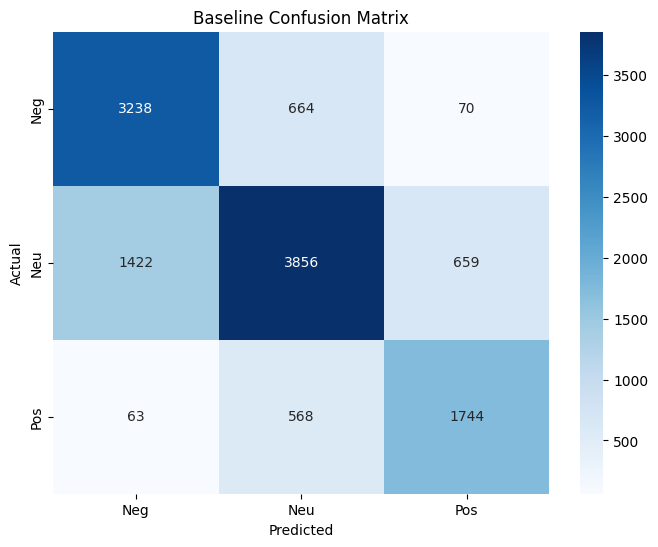

In [14]:
# Confusion Matrix
cm = confusion_matrix(df_test['label'], df_test['pred'])
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Neg', 'Neu', 'Pos'], 
            yticklabels=['Neg', 'Neu', 'Pos'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Baseline Confusion Matrix')
plt.show()


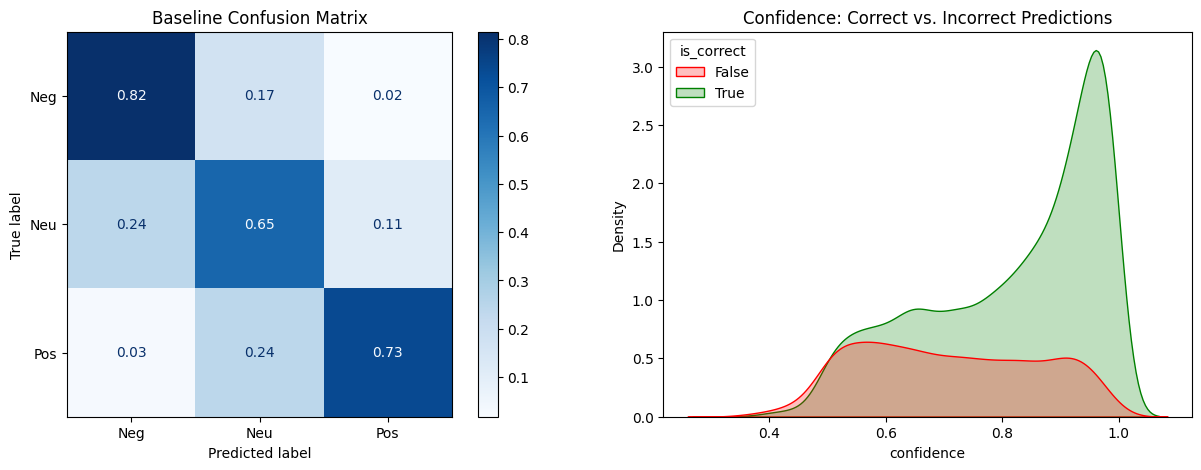

High Confidence Blunders (>85%): 783
Examples of High-Confidence Mistakes
                                                  text  label  pred  \
17   ISIS and The CIA What You Need To Know! #ISIS ...      1     0   
44   So that Westworld show, it isn't too bad. I gu...      1     2   
45       Grayson Allen just gave dude such a sick move      0     2   
67   Come on Electoral College. Please do your job....      1     0   
92   Power of 50+ years of unrelenting CIA propagan...      1     0   
99   @user Wow...this is one deadly statement! Remi...      2     0   
101  i bought it for kh3 and persona 5 and ffxiv (t...      2     1   
102  Drop 75% Price: £7.88. Paperback: The Gay & Le...      0     1   
109  @user Stay right here, buddy. There are lots o...      1     0   
144  4. One last time - #ArianaGrandehttps://t.co/0...      2     1   

     confidence  
17     0.908823  
44     0.975632  
45     0.943156  
67     0.902666  
92     0.861952  
99     0.926974  
101    0.853820  


In [15]:
df_test['is_correct'] = df_test['label'] == df_test['pred']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# 1. Normalized Confusion Matrix
cm = confusion_matrix(df_test['label'], df_test['pred'], normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neg', 'Neu', 'Pos'])
disp.plot(cmap='Blues', ax=axes[0], values_format='.2f')
axes[0].set_title("Baseline Confusion Matrix")

# 2. Confidence Density (Are we confidently wrong?)
sns.kdeplot(data=df_test, x="confidence", hue="is_correct", fill=True, 
            ax=axes[1], palette={True: "green", False: "red"})
axes[1].set_title("Confidence: Correct vs. Incorrect Predictions")
plt.show()

# Quick print of high-confidence failures
high_conf_errors = df_test[(~df_test['is_correct']) & (df_test['confidence'] > 0.85)]
print(f"High Confidence Blunders (>85%): {len(high_conf_errors)}")
print("Examples of High-Confidence Mistakes")
print(high_conf_errors[["text", "label", "pred", "confidence"]].head(10))
errors = df_test[df_test['label'] != df_test['pred']].copy()

In [16]:
# A. Polarity Flips
# These are often sarcasm, extreme idioms, or negation handling failures.
polarity_flips = errors[((errors['label'] == 0) & (errors['pred'] == 2)) | 
                        ((errors['label'] == 2) & (errors['pred'] == 0))]

# B. Under-sensitivity (Muted Sentiment: True Pos/Neg -> Pred Neutral)
# The model missed the emotional cue.
under_sensitive = errors[(errors['label'].isin([0, 2])) & (errors['pred'] == 1)]

# C. Over-sensitivity (Hallucinated Sentiment: True Neutral -> Pred Pos/Neg)
# The model overreacted to specific trigger words in an otherwise factual text.
over_sensitive = errors[(errors['label'] == 1) & (errors['pred'].isin([0, 2]))]

print("ERROR TYPE SUMMARY")
print(f"Total Test Samples: {len(df_test)}")
print(f"Total Errors: {len(errors)} (Error Rate: {len(errors)/len(df_test):.2%})")
print(f"1. Polarity Flips (Extreme Errors: True Pos -> Pred Neg OR True Neg -> Pred Pos): {len(polarity_flips)}")
print(f"2. Under-sensitive (Missed Emotion: True Pos/Neg -> Pred Neutral): {len(under_sensitive)}")
print(f"3. Over-sensitive (Hallucinated Emotion: True Neutral -> Pred Pos/Neg): {len(over_sensitive)}\n")

ERROR TYPE SUMMARY
Total Test Samples: 12284
Total Errors: 3446 (Error Rate: 28.05%)
1. Polarity Flips (Extreme Errors: True Pos -> Pred Neg OR True Neg -> Pred Pos): 133
2. Under-sensitive (Missed Emotion: True Pos/Neg -> Pred Neutral): 1232
3. Over-sensitive (Hallucinated Emotion: True Neutral -> Pred Pos/Neg): 2081



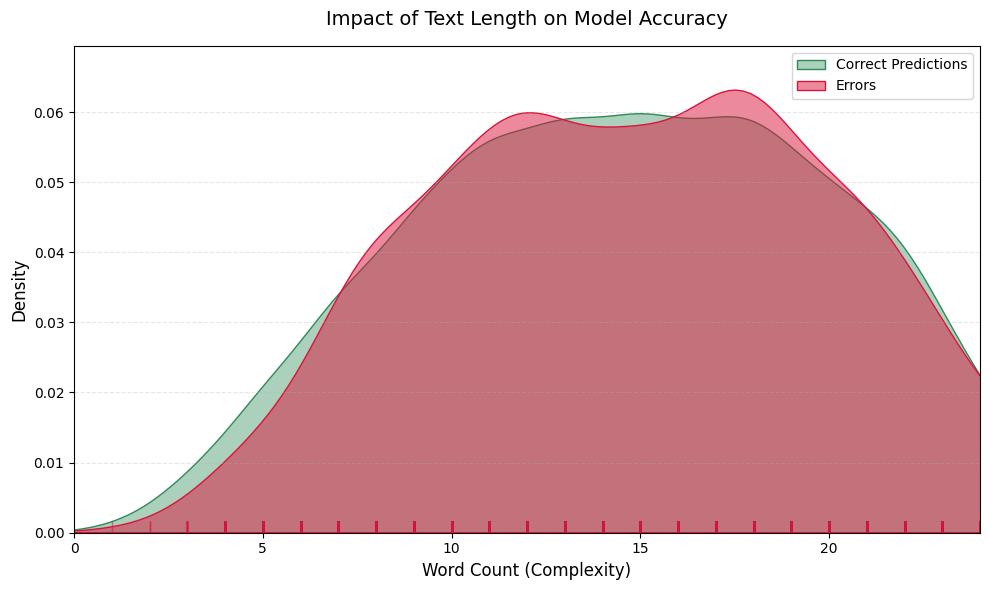

In [17]:
# TEXT LENGTH VS ERRORS ---

plt.figure(figsize=(10, 6))

# Define the data subsets for clarity
correct_preds = df_test[df_test['is_correct'] == True]
error_preds = df_test[df_test['is_correct'] == False]

# Create the KDE Plot
sns.kdeplot(data=correct_preds, x='word_count', fill=True, 
            label='Correct Predictions', color='seagreen', alpha=0.4)
sns.kdeplot(data=error_preds, x='word_count', fill=True, 
            label='Errors', color='crimson', alpha=0.5)

# Add a rug plot to show individual occurrences of errors
sns.rugplot(data=error_preds, x='word_count', color='crimson', alpha=.3)

# Formatting for Thesis-level quality
plt.title("Impact of Text Length on Model Accuracy", fontsize=14, pad=15)
plt.xlabel("Word Count (Complexity)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Set X-axis limit to ignore extreme outliers (95th percentile)
plt.xlim(0, df_test['word_count'].quantile(0.95))

plt.legend(frameon=True, facecolor='white')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# --- INSIGHT CALCULATION ---
avg_len_correct = correct_preds['word_count'].mean()
avg_len_error = error_preds['word_count'].mean()

print(f"📊 Insight Summary:")
print(f"- Average length of Correct samples: {avg_len_correct:.1f} words")
print(f"- Average length of Error samples: {avg_len_error:.1f} words")

if avg_len_error > avg_len_correct + 2:
    print("⚠️ Observation: Errors are shifting toward longer texts. The model may struggle with long-range dependencies.")
else:
    print("✅ Observation: Errors are distributed similarly to correct samples; length is likely not the primary failure driver.")

📊 Insight Summary:
- Average length of Correct samples: 14.8 words
- Average length of Error samples: 15.0 words
✅ Observation: Errors are distributed similarly to correct samples; length is likely not the primary failure driver.


In [19]:
# 6. INSPECTING 'HARD' EXAMPLES
pd.set_option('display.max_colwidth', None)

print("\n--- DEEP DIVE: POLARITY FLIPS (Potential Sarcasm or Negation Failures) ---")
display(polarity_flips[['text', 'label', 'pred', 'word_count']].head(5))

print("\n--- DEEP DIVE: OVER-SENSITIVE (Neutral labeled as Emotional) ---")
display(over_sensitive[['text', 'label', 'pred', 'word_count']].head(5))
# Create a dataframe of errors
errors = df_test[df_test['label'] != df_test['pred']].copy()

# Categorize errors
# Type A: False Positives (Labeled Neg, Predicted Pos) - The Sarcasm candidates!
false_positives = errors[(errors['label'] == 0) & (errors['pred'] == 2)]

# Type B: Subtle Neutrals (Labeled Neg/Pos, Predicted Neu)
false_neutrals = errors[errors['pred'] == 1]

print(f"Total Errors: {len(errors)}")
print(f"Sarcasm-style Errors (Neg labeled as Pos): {len(false_positives)}")
# Displaying the 'Hard' examples
pd.set_option('display.max_colwidth', None)
print("TOP SARCASM-LIKE ERRORS IN BASELINE:")
display(false_positives[['text', 'label', 'pred']].head(10))


--- DEEP DIVE: POLARITY FLIPS (Potential Sarcasm or Negation Failures) ---


,text,label,pred,word_count
45,Grayson Allen just gave dude such a sick move,0,2,9
99,@user Wow...this is one deadly statement! Reminding me of the Greta Muhammad Ali.,2,0,13
183,"Even after the 4th time watching #FantasticBeasts, I still teared up at the John Williams opening scores. Such a cry baby 😭",2,0,22
370,"Dear NO voters, are you celebrating your victory? So are Nigel Farage and Marine Le Pen. Enjoy the lovely company. #ItalyReferendum",0,2,21
485,Chinese scientists convert infectious viruses into live vaccines to tackle deadly viruses,2,0,12



--- DEEP DIVE: OVER-SENSITIVE (Neutral labeled as Emotional) ---


,text,label,pred,word_count
0,@user @user what do these '1/2 naked pics' have to do with anything? They're not even like that.,1,0,18
2,"@user @user That's coming, but I think the victims are going to be Medicaid recipients.",1,0,15
5,Savchenko now Saakashvili took drug test live on Ukraine TV. To prove they are not drug-fueled loonies?,1,0,17
6,How many more days until opening day? 😩,1,2,8
8,All CSG and Fracking all around Australia is to cease and Mining Entities held Accountable! - Sign the Petition!,1,0,19


Total Errors: 3446
Sarcasm-style Errors (Neg labeled as Pos): 70
TOP SARCASM-LIKE ERRORS IN BASELINE:


,text,label,pred
45,Grayson Allen just gave dude such a sick move,0,2
370,"Dear NO voters, are you celebrating your victory? So are Nigel Farage and Marine Le Pen. Enjoy the lovely company. #ItalyReferendum",0,2
535,Kim Fatty the Third 😂😂😂😂 China has excelled itself this time 👌,0,2
683,"@user Yeah, ima respect this Admin as much as they respected Obama's",0,2
757,#WESTWORLD Dolores is MF Wyatt mutherfuckerrrrrrr I don't think I've guessed one MF thing I love shows like this,0,2
922,Michelle Obama- Girl's Education- Brilliant- Role ModelMelania Trump- Nothing- Stole speech- Married Trump <-- that's saying enough,0,2
1018,"@user @user Look, I'm not gonna lie: that cut me deep. But with the help of Kim Jong-un I will get through this.",0,2
1025,Is this the best George soros could come up lots of love,0,2
1048,"@user @user Yeah, ok man. He's got more knowledge than you ever will. If he tried to get the popular vote, he would've.",0,2
1063,@user it would have felt better had we not had a Maduro or a Diosdado Cabello so the celebration wasn't as riveting lol,0,2


In [20]:
# --- GOLDEN SET: INFERENCE & CACHING ---
GOLDEN_PRED_PATH = os.path.join(parent_dir, "outputs", "predictions", "golden_predictions_seed42.csv")
GOLDEN_SOURCE_PATH = os.path.join(parent_dir, "data", "processed", "golden_set_clean.csv")

FORCE_RERUN_GOLD = False

if not os.path.exists(GOLDEN_PRED_PATH) or FORCE_RERUN_GOLD:
    if os.path.exists(GOLDEN_SOURCE_PATH):
        df_gold = pd.read_csv(GOLDEN_SOURCE_PATH)
        g_preds, g_confs = get_preds_with_confidence(model, tokenizer, df_gold['text'])
        df_gold['pred'] = g_preds
        df_gold['confidence'] = g_confs
        df_gold['is_correct'] = df_gold['label'].astype(int) == df_gold['pred'].astype(int)
        df_gold['word_count'] = df_gold['text'].apply(lambda x: len(str(x).split()))
        
        # Save results
        df_gold.to_csv(GOLDEN_PRED_PATH, index=False)
        print(f"Predictions of golden set saved to: {GOLDEN_PRED_PATH}")
else:
    print(f"Load Golden Set predictions from: {GOLDEN_PRED_PATH}")
    df_gold = pd.read_csv(GOLDEN_PRED_PATH)

Load Golden Set predictions from: /home/u538412/Thesis (final)/outputs/predictions/golden_predictions_seed42.csv


--- GOLDEN SET PERFORMANCE ---
              precision    recall  f1-score   support

         Neg       0.85      0.28      0.42        40
         Neu       0.50      0.54      0.52        13
         Pos       0.54      0.97      0.70        33

    accuracy                           0.58        86
   macro avg       0.63      0.59      0.54        86
weighted avg       0.68      0.58      0.54        86



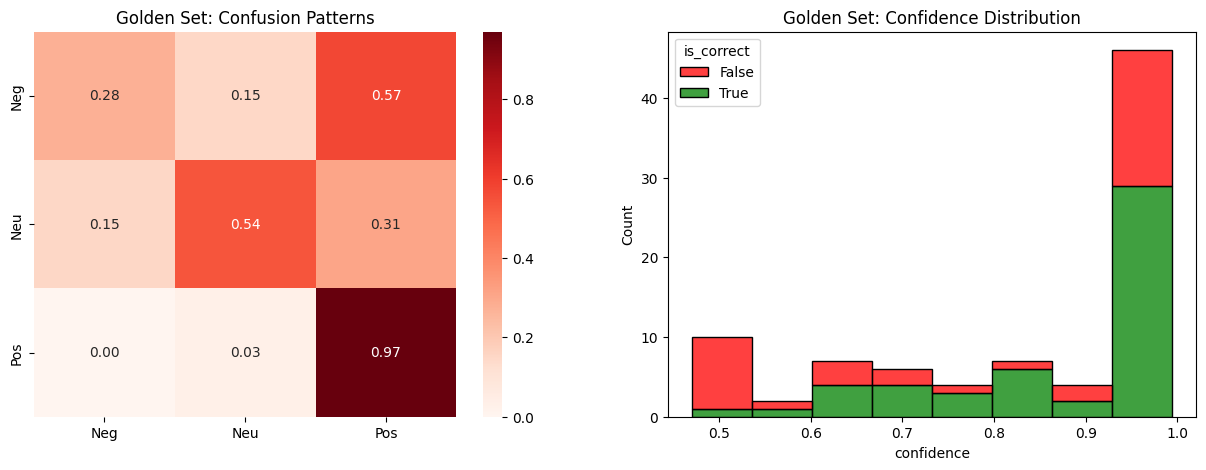


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
INSIGHT: TOP 'ARROGANT' ERRORS (Model is >90% confident but wrong)


,text,label,pred,confidence
9,"Spending my Saturday getting my car serviced is definitely the most enjoyable thing I could do with my time.""",0,2,0.994506
72,"""Oh goodie it's gonna be a snow storm tomorrow morning! Fun commute coming! Winter is awesome!",0,2,0.994284
7,"it's supposed to snow from midnight tonight until 6pm tomorrow? oh well that's friggin awesome""",0,2,0.993387
57,"Single awareness day is on Friday and I can't wait! #ValentinesDayCanSuckIt""",0,2,0.993246
37,"""Such a fun Saturday catching up on hw..",0,2,0.992388



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
INSIGHT: POLARITY FLIPS (Total: 23)


,text,label,pred,confidence
2,"""RT @katie_rohaley: School on Monday is just gonna be a great time",0,2,0.987888
3,"Thanks manager for putting me on the schedule for Sunday""",0,2,0.957839
7,"it's supposed to snow from midnight tonight until 6pm tomorrow? oh well that's friggin awesome""",0,2,0.993387
9,"Spending my Saturday getting my car serviced is definitely the most enjoyable thing I could do with my time.""",0,2,0.994506
11,"Hot Mess Monday! I'm feeling it! #runninglate #crazyday #blah #happymonday #lovemylife http://t.co/9gZzMtrkfp""",0,2,0.989800



💡 Statistical Note: Correlation between text length and accuracy: -0.169


In [21]:
# --- GOLDEN SET: DEEP ERROR ANALYSIS ---
print("--- GOLDEN SET PERFORMANCE ---")
print(classification_report(df_gold['label'], df_gold['pred'], target_names=['Neg', 'Neu', 'Pos']))

# 1. Failure Mode Categorization
# Polarity Flips (Serious errors)
gold_flips = df_gold[((df_gold['label'] == 0) & (df_gold['pred'] == 2)) | 
                     ((df_gold['label'] == 2) & (df_gold['pred'] == 0))]

# Arrogant Errors (Confident but wrong)
arrogant_errors = df_gold[(df_gold['is_correct'] == False) & (df_gold['confidence'] > 0.90)]

# 2. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix
cm_gold = confusion_matrix(df_gold['label'], df_gold['pred'], normalize='true')
sns.heatmap(cm_gold, annot=True, fmt='.2f', cmap='Reds', ax=axes[0],
            xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
axes[0].set_title("Golden Set: Confusion Patterns")

# Confidence vs Correctness
sns.histplot(data=df_gold, x="confidence", hue="is_correct", multiple="stack", 
             palette={True: "green", False: "red"}, ax=axes[1])
axes[1].set_title("Golden Set: Confidence Distribution")
plt.show()

# 3. Qualitative Deep Dive
pd.set_option('display.max_colwidth', 300)

print("\n" + "!"*60)
print("INSIGHT: TOP 'ARROGANT' ERRORS (Model is >90% confident but wrong)")
display(arrogant_errors.sort_values(by='confidence', ascending=False)[['text', 'label', 'pred', 'confidence']].head(5))

print("\n" + "!"*60)
print("INSIGHT: POLARITY FLIPS (Total: {})".format(len(gold_flips)))
display(gold_flips[['text', 'label', 'pred', 'confidence']].head(5))

# 4. Statistical Correlation
corr = df_gold['word_count'].corr(df_gold['is_correct'].astype(int))
print(f"\n💡 Statistical Note: Correlation between text length and accuracy: {corr:.3f}")